# 📌 Importação de bibliotecas

In [1]:
import numpy as np
import pandas as pd

In [3]:

import matplotlib.pyplot as plt

In [4]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

In [5]:
from scipy.stats import f_oneway
from scipy.stats import levene
import pingouin as pg

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate, KFold
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as imbpipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from yellowbrick.model_selection import FeatureImportances

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_squared_log_error, mean_absolute_percentage_error
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score
from sklearn.metrics import classification_report
from yellowbrick.classifier import ClassificationReport
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc, precision_recall_curve
)

In [8]:
import warnings

## Importação de pacotes locais

In [9]:

import telecomx.machine_learning as tml

## Configurações do ambiente

In [10]:
pd.set_option('display.max_columns', None)

In [11]:
warnings.simplefilter(action='ignore', category=FutureWarning)

## Constantes

In [12]:
NUM_SEMENTE_ALEATORIA = 42
TAMANHO_TESTE = 0.3
MAXIMO_ITERACAO = 1000

In [13]:
LIST_SCORING = ['accuracy','recall', 'precision', 'f1']

# 📌 Extração de dados

In [14]:
df_dados = pd.read_csv('./dados/dados_tratados.csv')

In [15]:
df_dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customerID                    7043 non-null   object 
 1   Churn                         7043 non-null   int64  
 2   customer_gender               7043 non-null   object 
 3   customer_SeniorCitizen        7043 non-null   int64  
 4   customer_Partner              7043 non-null   int64  
 5   customer_Dependents           7043 non-null   int64  
 6   customer_tenure               7043 non-null   int64  
 7   phone_PhoneService            7043 non-null   int64  
 8   phone_MultipleLines           7043 non-null   int64  
 9   internet_InternetService      7043 non-null   int64  
 10  internet_OnlineSecurity       7043 non-null   int64  
 11  internet_OnlineBackup         7043 non-null   int64  
 12  internet_DeviceProtection     7043 non-null   int64  
 13  int

In [16]:
df_dados.nunique()

customerID                      7043
Churn                              2
customer_gender                    2
customer_SeniorCitizen             2
customer_Partner                   2
customer_Dependents                2
customer_tenure                   72
phone_PhoneService                 2
phone_MultipleLines                2
internet_InternetService           2
internet_OnlineSecurity            2
internet_OnlineBackup              2
internet_DeviceProtection          2
internet_TechSupport               2
internet_StreamingTV               2
internet_StreamingMovies           2
account_Contract                   3
account_PaperlessBilling           2
account_PaymentMethod              4
account_Charges_Monthly         1585
account_Charges_Total           6534
internet_Service_Description       3
customer_tenure_bins               6
account_Charges_Monthly_bins       6
account_Charges_Total_bins        13
account_Contract_Monthly           2
additional_InternetService         7
o

Verificar dados duplicados

In [17]:
df_dados.duplicated().sum()

0

# 📌 Tratamento de dados

In [18]:
df_ohe = tml.df_final_modelo_v1(df_dados)

# 📌 Seleção e validação dos modelos de treinamento

## Tabela de verificação de padronização dos dados

| Modelo                 | Precisa padronizar? | Tipo de padronização (se necessário)   |
| ---------------------- | ------------------- | -------------------------------------- |
| DecisionTreeClassifier | ❌ Não               | —                                      |
| LogisticRegression     | ✅ Sim               | `StandardScaler` (média 0, desvio 1)   |
| RandomForest           | ❌ Não               | —                                      |
| XGBoost                | ⚠️ Opcional         | Pode ajudar (StandardScaler ou MinMax) |
| LightGBM               | ⚠️ Opcional         | Pode ajudar (StandardScaler ou MinMax) |
| CatBoost               | ❌ Não               | —                                      |


## Conceitos sobre as métricas de um modelo

Aqui está o quadro comparativo para churn (evasão de clientes), considerando que a classe positiva é “cliente vai sair”:

| **Métrica**                | **O que mede**                                                                     | **Quando valor é alto**                                        | **Risco quando valor é baixo**                                   | **Custo de erro associado**                                                |
| -------------------------- | ---------------------------------------------------------------------------------- | -------------------------------------------------------------- | ---------------------------------------------------------------- | -------------------------------------------------------------------------- |
| **Precisão (Precision)**   | Entre todos que o modelo previu como “vai sair”, qual porcentagem realmente saiu   | Você gasta retenção apenas em quem de fato sairia              | Gastar recursos em retenção de clientes que iam ficar (FP alto)  | **Custo financeiro** com campanhas desnecessárias (descontos, bônus, etc.) |
| **Recall (Sensibilidade)** | Entre todos que realmente saíram, qual porcentagem o modelo previu como “vai sair” | Você identifica a maior parte dos clientes que iam sair        | Deixar escapar clientes que saem (FN alto)                       | **Perda de receita** e potencial perda de market share                     |
| **F1-Score**               | Média harmônica de precisão e recall                                               | Equilíbrio entre acertar quem vai sair e evitar falsos alarmes | Ou alto custo de retenção inútil ou perda de clientes — ou ambos | **Equilíbrio financeiro e estratégico** — custo total menor                |
| **FP (Falso Positivo)**    | Previu saída, mas o cliente ficaria                                                | —                                                              | Gastar para reter quem não ia sair                               | Desperdício de budget de retenção                                          |
| **FN (Falso Negativo)**    | Previu permanência, mas o cliente saiu                                             | —                                                              | Não agir para reter quem realmente sairia                        | Perda direta de receita + possível impacto na reputação                    |
    

📌 Resumo visual da prioridade

    Se retenção for muito cara → priorizar alta precisão.

    Se perder clientes for muito prejudicial → priorizar alto recall.

    Se quer balancear ambos → otimizar F1-Score.

## Split base de dados em train e test

In [19]:
X = df_ohe.drop(columns=['Churn'])

In [20]:
y = df_ohe.Churn

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = NUM_SEMENTE_ALEATORIA, test_size=TAMANHO_TESTE, stratify=y)

## Treinamento do Modelo - LogisticRegression

### Exige padronização dos dados

In [22]:
pipeline_lr = imbpipeline([
    ('Scaler', StandardScaler()),
    ('LogisticRegression', LogisticRegression(max_iter=MAXIMO_ITERACAO, random_state=NUM_SEMENTE_ALEATORIA))
])

In [23]:
skf = StratifiedKFold(n_splits= 5, shuffle= True, random_state= NUM_SEMENTE_ALEATORIA)
cv_resultados = cross_validate(pipeline_lr, X, y, cv= skf, scoring= LIST_SCORING)

In [24]:
for ls in LIST_SCORING:
    teste_ls = f'test_{ls}'
    print('')
    tml.intervalo_conf(cv_resultados, teste_ls)


Tipo de teste: test_accuracy
Média: 0.8035
Desvio padrão: 0.0058
Intervalo de confiança entre: 0.7919 e 0.8151

Tipo de teste: test_recall
Média: 0.5211
Desvio padrão: 0.0283
Intervalo de confiança entre: 0.4645 e 0.5778

Tipo de teste: test_precision
Média: 0.6657
Desvio padrão: 0.0109
Intervalo de confiança entre: 0.6439 e 0.6876

Tipo de teste: test_f1
Média: 0.5842
Desvio padrão: 0.0192
Intervalo de confiança entre: 0.5458 e 0.6227


In [25]:
cv_resultados

{'fit_time': array([0.04500031, 0.03599882, 0.01999807, 0.02296424, 0.0250001 ]),
 'score_time': array([0.02400041, 0.01300001, 0.01203203, 0.01400304, 0.01600552]),
 'test_accuracy': array([0.8133428 , 0.79843861, 0.80624556, 0.79758523, 0.80184659]),
 'test_recall': array([0.57486631, 0.51336898, 0.51871658, 0.50670241, 0.49197861]),
 'test_precision': array([0.67398119, 0.65306122, 0.67595819, 0.65172414, 0.67399267]),
 'test_f1': array([0.62049062, 0.5748503 , 0.58698941, 0.57013575, 0.56877898])}

In [26]:
pipeline_lr.fit(X_train, y_train)

Pipeline(steps=[('Scaler', StandardScaler()),
                ('LogisticRegression',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [27]:
y_pred_pipe_lr = pipeline_lr.predict(X_test)
y_pred_proba_pipe_lr = pipeline_lr.predict_proba(X_test)

### Relatório de métricas

Métricas:
Acurácia: 0.7937
Precisão: 0.6321
Recall: 0.5330
F1-Score: 0.5783
ROC AUC: 0.8311

Relatório de classificação:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1552
           1       0.63      0.53      0.58       561

    accuracy                           0.79      2113
   macro avg       0.74      0.71      0.72      2113
weighted avg       0.78      0.79      0.79      2113


Matrix de confusão:

[[1378  174]
 [ 262  299]]


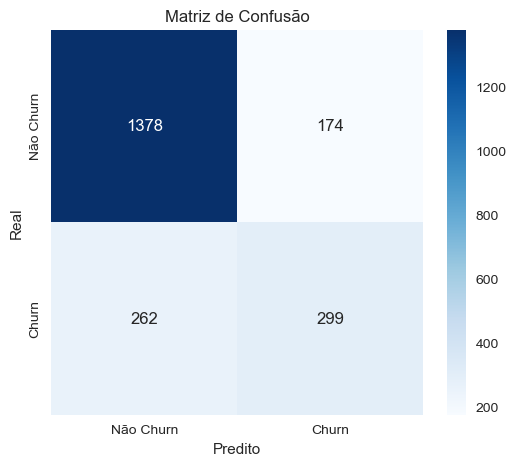

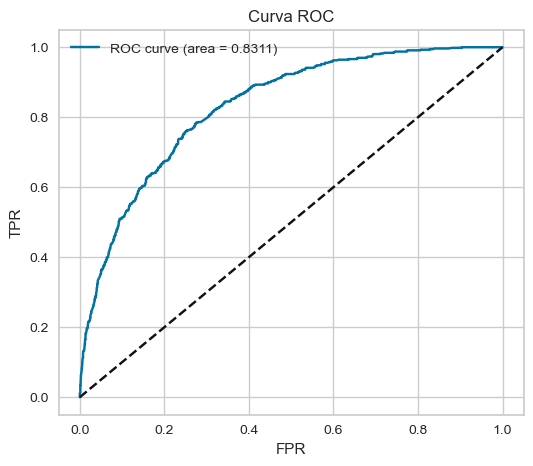

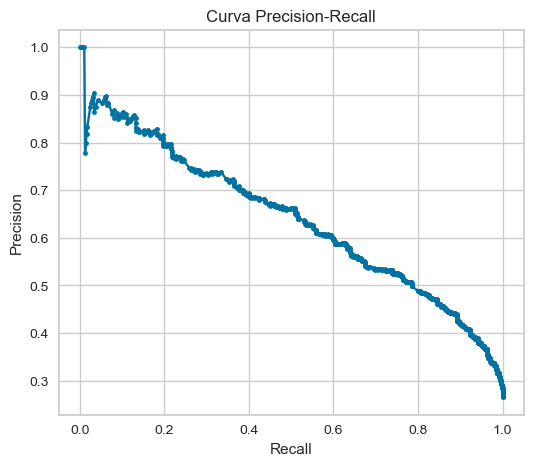

In [28]:
tml.avaliar_modelo(y_test, y_pred_pipe_lr, y_pred_proba_pipe_lr)

### Importância de features

In [29]:
pipeline_lr.named_steps.get('LogisticRegression')

LogisticRegression(max_iter=1000, random_state=42)

In [30]:
# Acessando o modelo treinado dentro do pipeline
logreg_model = pipeline_lr.named_steps.get('LogisticRegression')

In [31]:
# Supondo que X_train é um DataFrame
coeficientes = logreg_model.coef_[0]  # Para binário, só há uma linha

# Criar um DataFrame com as features e seus coeficientes
df_importance_lr = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficient': coeficientes,
    'Absolute_importance': np.abs(coeficientes)
})

# Ordenar pela importância absoluta
df_importance_lr = df_importance_lr.sort_values(by='Absolute_importance', ascending=False)

In [32]:
df_importance_lr

,Feature,Coeficient,Absolute_importance
7,internet_Service_Description_Fiber_optic,1.226351,1.226351
8,charges_total_bin__inf_96_62_,0.646564,0.646564
6,internet_Service_Description_DSL,0.561236,0.561236
5,account_Contract_Monthly,0.528641,0.528641
16,charges_total_bin__6623_50_inf_,-0.391052,0.391052
15,charges_total_bin__5644_60_6623_50_,-0.302924,0.302924
13,charges_total_bin__4838_38_5644_60_,-0.286368,0.286368
11,charges_total_bin__3273_68_4838_38_,-0.284124,0.284124
17,charges_total_bin__96_62_198_05_,0.268925,0.268925
4,account_PaperlessBilling,0.240527,0.240527


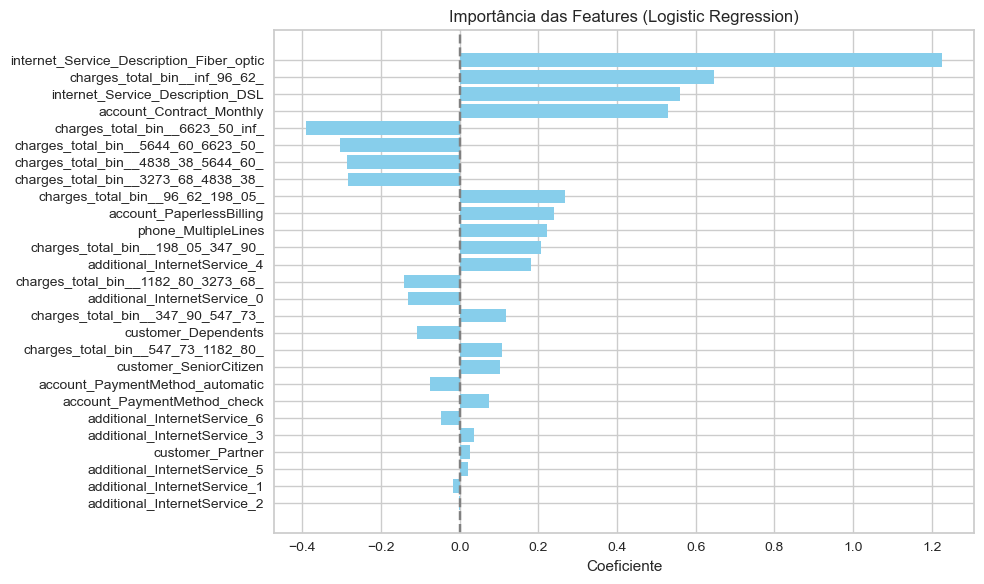

In [33]:
plt.figure(figsize=(10,6))
plt.barh(df_importance_lr.Feature, df_importance_lr.Coeficient, color='skyblue')
plt.axvline(0, color='gray', linestyle='--')
plt.xlabel('Coeficiente')
plt.title('Importância das Features (Logistic Regression)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Otimização de hiperparâmetros

### Otimizando os hiperparâmetros com o GridSearchCV

In [34]:
logreg_model.get_params().keys()

dict_keys(['C', 'class_weight', 'dual', 'fit_intercept', 'intercept_scaling', 'l1_ratio', 'max_iter', 'multi_class', 'n_jobs', 'penalty', 'random_state', 'solver', 'tol', 'verbose', 'warm_start'])

In [35]:
param_grid = {
    'LogisticRegression__C': [0.01, 0.1, 1, 10, 100],
    'LogisticRegression__penalty': ['l1', 'l2'],
    'LogisticRegression__class_weight': [None, 'balanced'],
}

In [36]:
model_grid_lr = GridSearchCV(
    estimator=pipeline_lr,
    param_grid=param_grid,
    cv=5,
    scoring='recall',  # ou 'f1', 'roc_auc'
    n_jobs=-1,
    verbose=2
)

In [37]:
model_grid_lr.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1151, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\imblearn\pipeline.py", line 526, in fit
    self._final_estimator.f

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Scaler', StandardScaler()),
                                       ('LogisticRegression',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'LogisticRegression__C': [0.01, 0.1, 1, 10, 100],
                         'LogisticRegression__class_weight': [None, 'balanced'],
                         'LogisticRegression__penalty': ['l1', 'l2']},
             scoring='recall', verbose=2)

In [38]:
model_grid_lr.best_params_

{'LogisticRegression__C': 0.01,
 'LogisticRegression__class_weight': 'balanced',
 'LogisticRegression__penalty': 'l2'}

In [39]:
model_grid_lr.score

<bound method BaseSearchCV.score of GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('Scaler', StandardScaler()),
                                       ('LogisticRegression',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'LogisticRegression__C': [0.01, 0.1, 1, 10, 100],
                         'LogisticRegression__class_weight': [None, 'balanced'],
                         'LogisticRegression__penalty': ['l1', 'l2']},
             scoring='recall', verbose=2)>

In [40]:
y_pred_grid_lr = model_grid_lr.predict(X_test)

In [41]:
y_pred_proba_grid_lr = model_grid_lr.predict_proba(X_test)

### Relatório de métricas

In [42]:
tml.df_classifier_metrics(y_test, y_pred_pipe_lr, y_pred_proba_pipe_lr, ['LR - StandardScaler'])

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
LR - StandardScaler,0.793658,0.632135,0.532977,0.578337,0.831083,2113,1378,174,262,299


In [43]:
tml.df_classifier_metrics(y_test, y_pred_grid_lr, y_pred_proba_grid_lr, ['LR - StandardScaler - Grid'])

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
LR - StandardScaler - Grid,0.732608,0.497743,0.786096,0.609537,0.82821,2113,1107,445,120,441


In [44]:
tml.avaliar_modelo(y_test, y_pred_pipe_lr, y_pred_proba_pipe_lr, False)

Métricas:
Acurácia: 0.7937
Precisão: 0.6321
Recall: 0.5330
F1-Score: 0.5783
ROC AUC: 0.8311

Relatório de classificação:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1552
           1       0.63      0.53      0.58       561

    accuracy                           0.79      2113
   macro avg       0.74      0.71      0.72      2113
weighted avg       0.78      0.79      0.79      2113


Matrix de confusão:

[[1378  174]
 [ 262  299]]


In [45]:
tml.avaliar_modelo(y_test, y_pred_grid_lr, y_pred_proba_grid_lr, False)

Métricas:
Acurácia: 0.7326
Precisão: 0.4977
Recall: 0.7861
F1-Score: 0.6095
ROC AUC: 0.8282

Relatório de classificação:

              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1552
           1       0.50      0.79      0.61       561

    accuracy                           0.73      2113
   macro avg       0.70      0.75      0.70      2113
weighted avg       0.79      0.73      0.75      2113


Matrix de confusão:

[[1107  445]
 [ 120  441]]


### Balanceamento com Oversampling

In [46]:
pipeline_blover_lr = imbpipeline([
    ('oversample', SMOTE(random_state=NUM_SEMENTE_ALEATORIA)),
    ('Scaler', StandardScaler()),
    ('LogisticRegression', LogisticRegression(max_iter=MAXIMO_ITERACAO, random_state=NUM_SEMENTE_ALEATORIA))
])

In [47]:
model_grid_blover_lr = GridSearchCV(
    estimator=pipeline_blover_lr,
    param_grid=param_grid,
    cv=5,
    scoring='recall',  # ou 'f1', 'roc_auc'
    n_jobs=-1,
    verbose=2
)

In [48]:
model_grid_blover_lr.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
50 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
50 fits failed with the following error:
Traceback (most recent call last):
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 732, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py", line 1151, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\ProgramData\anaconda3\Lib\site-packages\imblearn\pipeline.py", line 526, in fit
    self._final_estimator.f

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('oversample', SMOTE(random_state=42)),
                                       ('Scaler', StandardScaler()),
                                       ('LogisticRegression',
                                        LogisticRegression(max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1,
             param_grid={'LogisticRegression__C': [0.01, 0.1, 1, 10, 100],
                         'LogisticRegression__class_weight': [None, 'balanced'],
                         'LogisticRegression__penalty': ['l1', 'l2']},
             scoring='recall', verbose=2)

In [49]:
model_grid_lr.best_params_

{'LogisticRegression__C': 0.01,
 'LogisticRegression__class_weight': 'balanced',
 'LogisticRegression__penalty': 'l2'}

In [50]:
model_grid_blover_lr.best_params_

{'LogisticRegression__C': 0.01,
 'LogisticRegression__class_weight': None,
 'LogisticRegression__penalty': 'l2'}

In [51]:
y_pred_grid_blover_lr = model_grid_blover_lr.predict(X_test)

In [52]:
y_pred_proba_grid_blover_lr = model_grid_blover_lr.predict_proba(X_test)

### Relatório de métricas

In [53]:
tml.df_classifier_metrics(y_test, y_pred_grid_blover_lr, y_pred_proba_grid_blover_lr, ['LR - StandardScaler - Grid - Oversampling'])

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
LR - StandardScaler - Grid - Oversampling,0.735447,0.501166,0.766488,0.606061,0.823329,2113,1124,428,131,430


In [54]:
tml.avaliar_modelo(y_test, y_pred_grid_blover_lr, y_pred_proba_grid_blover_lr, False)

Métricas:
Acurácia: 0.7354
Precisão: 0.5012
Recall: 0.7665
F1-Score: 0.6061
ROC AUC: 0.8233

Relatório de classificação:

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1552
           1       0.50      0.77      0.61       561

    accuracy                           0.74      2113
   macro avg       0.70      0.75      0.70      2113
weighted avg       0.79      0.74      0.75      2113


Matrix de confusão:

[[1124  428]
 [ 131  430]]


### Consolidação das métricas

In [55]:
df_metricas = []

df_metricas.append(tml.df_classifier_metrics(y_test, y_pred_pipe_lr, y_pred_proba_pipe_lr, ['LR - StandardScaler']))

df_metricas.append(tml.df_classifier_metrics(y_test, y_pred_grid_lr, y_pred_proba_grid_lr, ['LR - StandardScaler - Grid']))

df_metricas.append(tml.df_classifier_metrics(y_test, y_pred_grid_blover_lr, y_pred_proba_grid_blover_lr, ['LR - StandardScaler - Grid - Oversampling']))

In [56]:
df_metricas = pd.concat(df_metricas, axis=0)
df_metricas

,accuracy,precision,recall,f1,roc_auc,support,True Negative,False Positive,False Negative,True Positive
LR - StandardScaler,0.793658,0.632135,0.532977,0.578337,0.831083,2113,1378,174,262,299
LR - StandardScaler - Grid,0.732608,0.497743,0.786096,0.609537,0.828210,2113,1107,445,120,441
LR - StandardScaler - Grid - Oversampling,0.735447,0.501166,0.766488,0.606061,0.823329,2113,1124,428,131,430


In [57]:
df_metricas.to_clipboard()